In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix
)

from sklearn.decomposition import PCA
from mlxtend.plotting import plot_decision_regions

In [3]:
# Load Dataset Directly from GitHub
url = "https://raw.githubusercontent.com/Mehedi752/AI-ML-Lab/refs/heads/main/DT/dataset/data.csv"
df = pd.read_csv(url)

# View First 5 Rows
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [4]:
# Dataset Exploration

# 1.Shape of Dataset
print("Shape of Dataset:")
print(df.shape)

# 2.Display 5 Random Samples
print("5 Random Samples:")
print(df.sample(5))

# 3.Dataset Information
print("Dataset Info:")
df.info()

# 4.Statistical Summary
print("Statistical Summary:")
print(df.describe())

# 5.Number of unique values in each column.
print("Number of Unique Values in Each Column:")
print(df.nunique())

# 6.Check Missing Values
print("Missing Values:")
print(df.isnull().sum())

# 7.Check Duplicate Rows
print("Duplicate Rows:")
print(df.duplicated().sum())

# 8.Memory Usage
print("Memory Usage:")
print(df.memory_usage())

# 9.Check Skewness
print("Skewness:")
print(df.skew(numeric_only=True))


Shape of Dataset:
(569, 33)
5 Random Samples:
           id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
327    895299         B        12.03         17.93           76.09      446.0   
526  91813701         B        13.46         18.75           87.44      551.1   
146    869691         M        11.80         16.58           78.99      432.0   
230    881972         M        17.05         19.08          113.40      895.0   
535    919555         M        20.55         20.86          137.80     1308.0   

     smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
327          0.07683           0.03892        0.001546             0.005592   
526          0.10750           0.11380        0.042010             0.031520   
146          0.10910           0.17000        0.165900             0.074150   
230          0.11410           0.15720        0.191000             0.109000   
535          0.10460           0.17390        0.208500             0.132

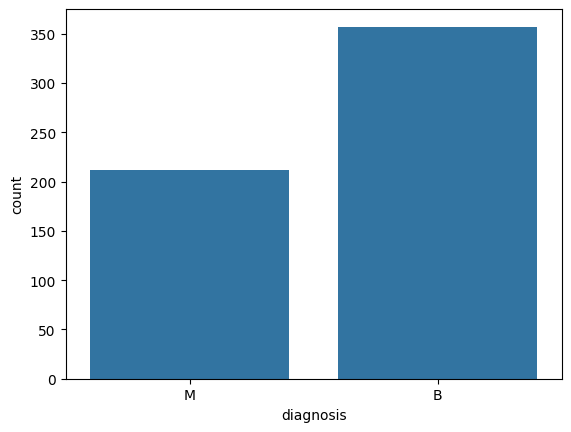

In [5]:
# Class Distribution
sns.countplot(x=df["diagnosis"])
plt.show()

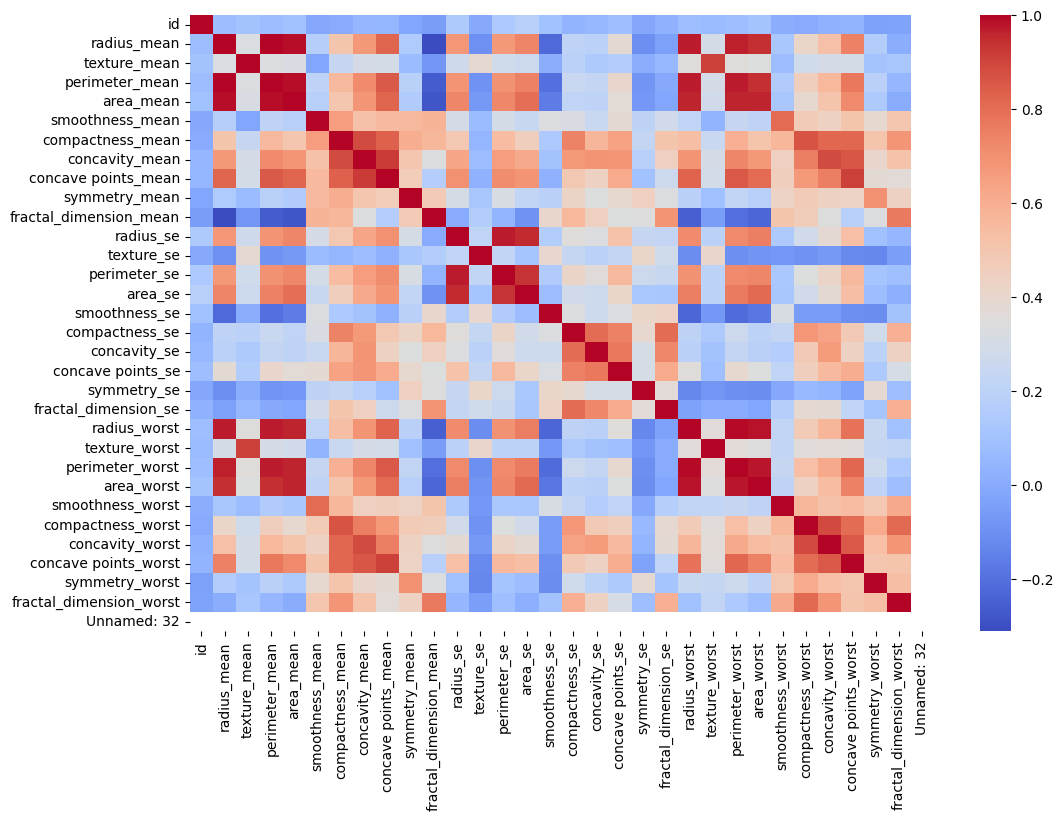

In [6]:
# Correlation Heatmap
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap='coolwarm'
)

plt.show()

In [26]:
# Data Preprocessing

# Drop the 'Unnamed: 32' column if it exists
if 'Unnamed: 32' in df.columns:
    df = df.drop('Unnamed: 32', axis=1)

# Apply LabelEncoder to 'diagnosis' column and create a new encoded column
le = LabelEncoder()
df['diagnosis_encoded'] = le.fit_transform(df['diagnosis'])

# Features Selection
feature_columns = [col for col in df.columns if col not in ['id', 'diagnosis', 'diagnosis_encoded']]
X = df[feature_columns]
y = df['diagnosis_encoded']

In [27]:
# Scalling/Normalization
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [28]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [29]:
# CART Implementation (Gini)
cart_params = {
    "max_depth":[3,5,7,10,None],
    "min_samples_split":[2,5,10]
}

cart_grid = GridSearchCV(
    DecisionTreeClassifier(
        criterion="gini",
        random_state=42
    ),
    cart_params,
    cv=5
)
cart_grid.fit(X_train,y_train)

cart = cart_grid.best_estimator_

In [30]:
# ID3 Implementation (Entropy)
criterion="entropy"
id3_params = {
    "max_depth":[3,5,7,10,None],
    "min_samples_split":[2,5,10]
}
id3_grid = GridSearchCV(
    DecisionTreeClassifier(
        criterion="entropy",
        random_state=42
    ),
    id3_params,
    cv=5
)

id3_grid.fit(X_train,y_train)

id3 = id3_grid.best_estimator_

In [31]:
# Predictions
cart_pred = cart.predict(X_test)
cart_prob = cart.predict_proba(X_test)[:,1]

id3_pred = id3.predict(X_test)
id3_prob = id3.predict_proba(X_test)[:,1]

In [32]:
# Metrics
def get_metrics(y_true,y_pred,y_prob):

    return {
        "Accuracy":
        accuracy_score(y_true,y_pred),

        "Precision":
        precision_score(y_true,y_pred),

        "Recall":
        recall_score(y_true,y_pred),

        "F1":
        f1_score(y_true,y_pred),

        "AUC":
        roc_auc_score(y_true,y_prob)
    }

cart_metrics = get_metrics(
    y_test,
    cart_pred,
    cart_prob
)

id3_metrics = get_metrics(
    y_test,
    id3_pred,
    id3_prob
)

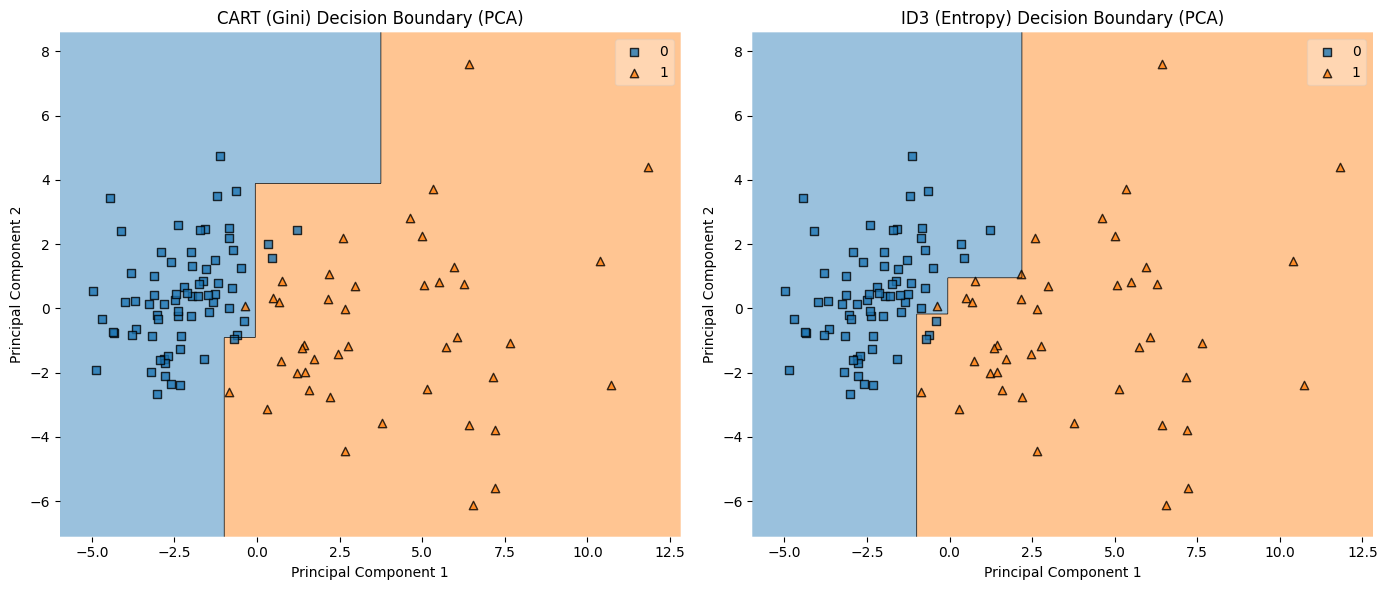

In [35]:
# Decision Boundary Plot (2x1)

# 1. Initialize PCA
pca = PCA(n_components=2)

# 2. Fit PCA on the scaled training data and transform both train and test data
pca.fit(X_train)
X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)

# 3. Train new Decision Tree Classifiers on the PCA-transformed training data
cart_pca_clf = DecisionTreeClassifier(
    criterion=cart.criterion,
    max_depth=cart.max_depth,
    min_samples_split=cart.min_samples_split,
    random_state=42
)
cart_pca_clf.fit(X_train_pca, y_train) # y_train is the correct target for X_train_pca

id3_pca_clf = DecisionTreeClassifier(
    criterion=id3.criterion,
    max_depth=id3.max_depth,
    min_samples_split=id3.min_samples_split,
    random_state=42
)
id3_pca_clf.fit(X_train_pca, y_train) # y_train is the correct target for X_train_pca

# 4. Create subplots
fig, ax = plt.subplots(
    1,
    2,
    figsize=(14,6)
)

# 5. Plot decision regions for CART (Gini)
plot_decision_regions(
    X_test_pca,
    y_test.values,
    clf=cart_pca_clf,
    ax=ax[0]
)
ax[0].set_title('CART (Gini) Decision Boundary (PCA)')
ax[0].set_xlabel('Principal Component 1')
ax[0].set_ylabel('Principal Component 2')


# 6. Plot decision regions for ID3 (Entropy)
plot_decision_regions(
    X_test_pca,
    y_test.values,
    clf=id3_pca_clf,
    ax=ax[1]
)
ax[1].set_title('ID3 (Entropy) Decision Boundary (PCA)')
ax[1].set_xlabel('Principal Component 1')
ax[1].set_ylabel('Principal Component 2')

plt.tight_layout()
plt.show()

Text(627.9949494949494, 0.5, 'Actual')

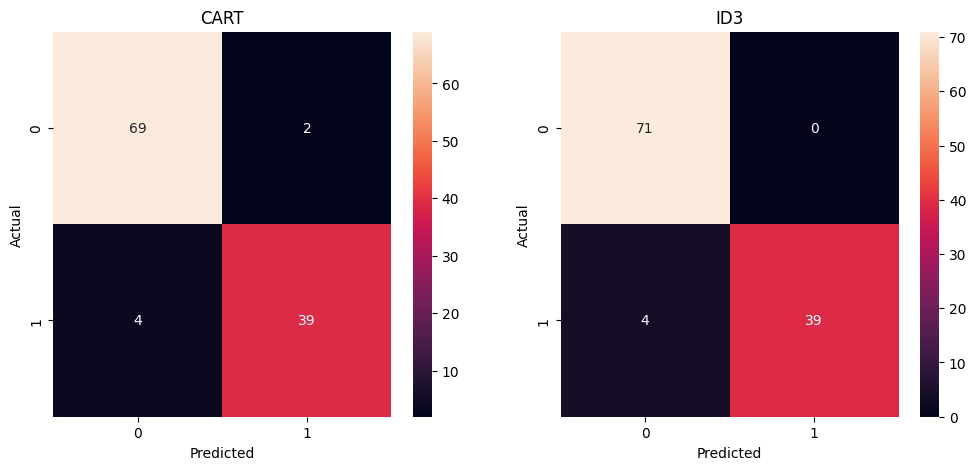

In [39]:
# Confusion Matrix (2x1)
fig, ax = plt.subplots(
    1,
    2,
    figsize=(12,5)
)

sns.heatmap(
    confusion_matrix(y_test,cart_pred),
    annot=True,
    fmt='d',
    ax=ax[0]
)

ax[0].set_title("CART")

sns.heatmap(
    confusion_matrix(y_test,id3_pred),
    annot=True,
    fmt='d',
    ax=ax[1]
)

ax[1].set_title("ID3")

ax[0].set_xlabel("Predicted")
ax[0].set_ylabel("Actual")

ax[1].set_xlabel("Predicted")
ax[1].set_ylabel("Actual")

Text(0, 0.5, 'True Positive Rate')

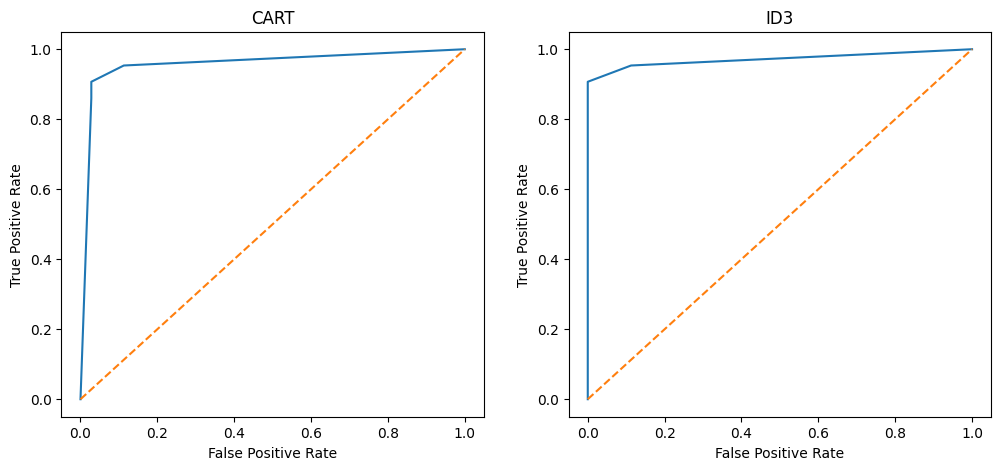

In [38]:
# ROC Curve (2x1)
fig, ax = plt.subplots(
    1,
    2,
    figsize=(12,5)
)

fpr,tpr,_ = roc_curve(
    y_test,
    cart_prob
)

ax[0].plot(fpr,tpr)
ax[0].plot([0,1],[0,1],'--')

fpr,tpr,_ = roc_curve(
    y_test,
    id3_prob
)

ax[1].plot(fpr,tpr)
ax[1].plot([0,1],[0,1],'--')

ax[0].set_title("CART")
ax[1].set_title("ID3")

ax[0].set_xlabel("False Positive Rate")
ax[0].set_ylabel("True Positive Rate")

ax[1].set_xlabel("False Positive Rate")
ax[1].set_ylabel("True Positive Rate")


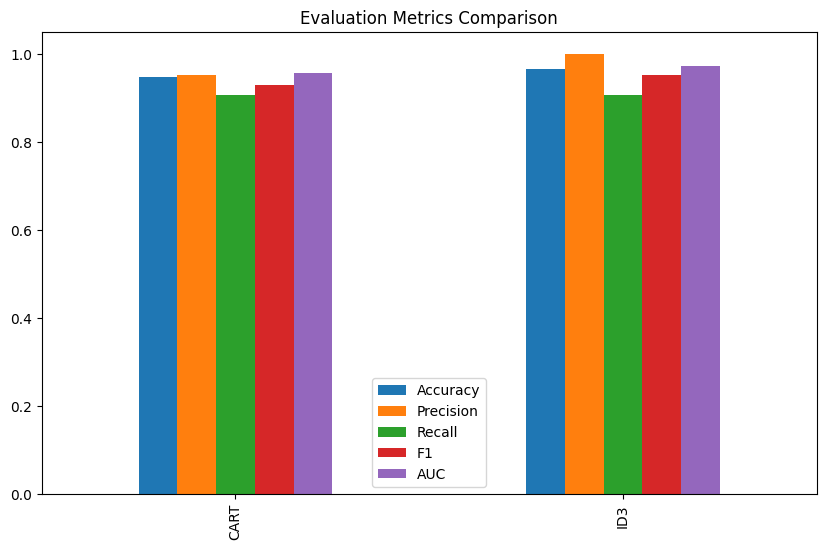

In [41]:
# Evaluation Metrics
metrics_df = pd.DataFrame(
    [cart_metrics,id3_metrics],
    index=["CART","ID3"]
)

metrics_df.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title(
    "Evaluation Metrics Comparison"
)

plt.show()

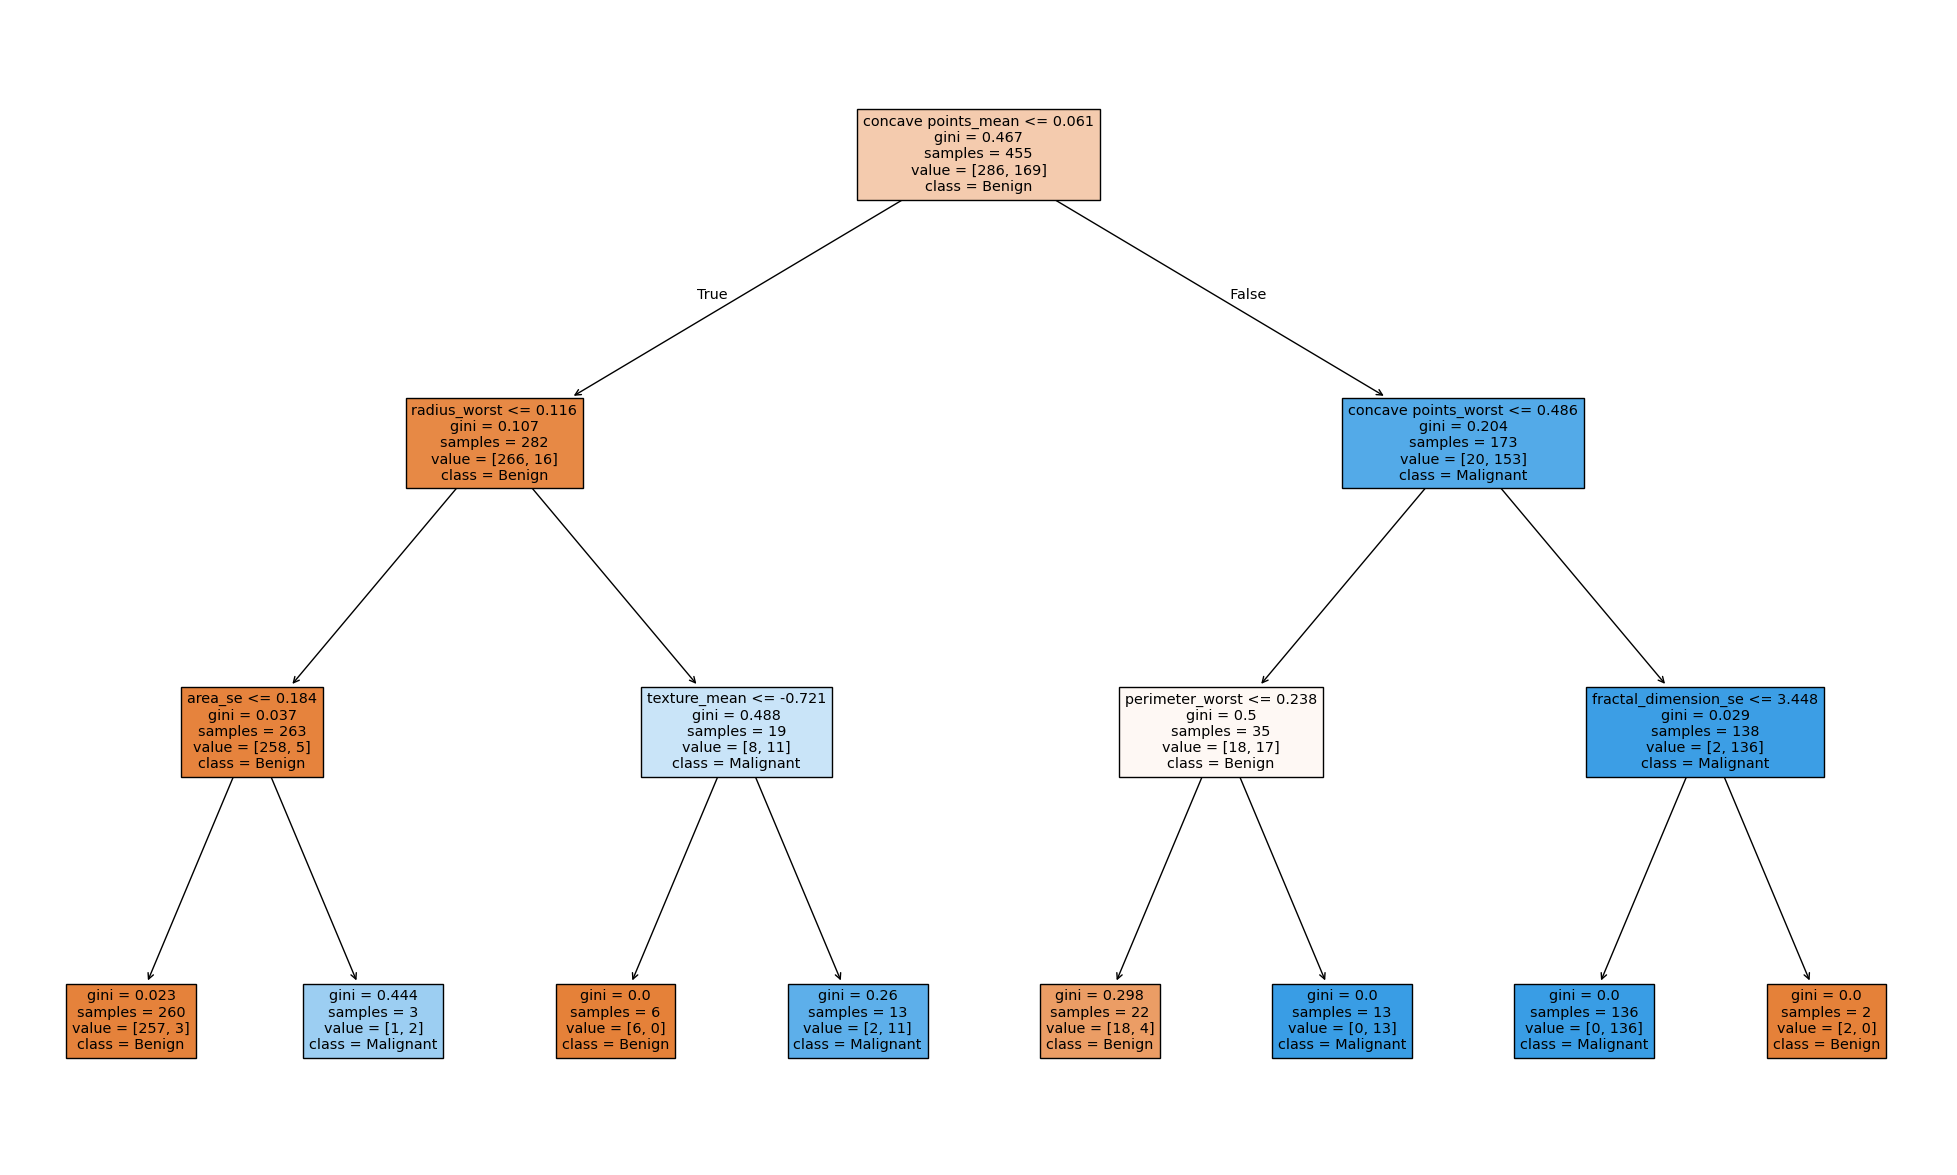

In [44]:
# DT Structure
plt.figure(
    figsize=(25,15)
)

plot_tree(
    cart,
    filled=True,
    feature_names=X.columns,
    class_names=["Benign","Malignant"]
)

plt.show()

In [43]:
# Conclusion:
# In this project, two Decision Tree algorithms, CART (Gini Index) and ID3 (Entropy), were implemented and compared using the
# Breast Cancer Wisconsin dataset. Hyperparameter tuning was performed using GridSearchCV to optimize max_depth and
# min_samples_split values.